In [11]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
from resonator import Model_fit

In [12]:
from scipy.optimize import curve_fit

In [21]:
import os
import lmfit

In [16]:
def resonator_fit_from_dir(dirname,fit=True):
    header = "D:/K_sunada/database/"
    dd = datadict_from_hdf5(header+dirname+"/data")
    s11 = dd['s11']['values']
    f = dd['frequency']['values']
    if fit:
        result = Model_fit(f,s11)
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[0].plot(f, np.abs(result.init_fit), '--', label='initial fit', color='orange')
        ax[0].plot(f, np.abs(result.best_fit), '-', label='best fit', color='red')
        ax[0].legend()
        ax[1].plot(f, np.angle(s11), '.', color='k')
        ax[1].plot(f, np.angle(result.init_fit), '--', label='initial fit', color='orange')
        ax[1].plot(f, np.angle(result.best_fit), '-', label='best fit', color='red')
        ax[1].legend()

        return result
    else:
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[1].plot(f, np.angle(s11), '.', color='k')
        return f, s11, fig, ax

d:\K_Sunada\.venv\lib\site-packages\lmfit\printfuncs.py:372: RuntimeWarning: divide by zero encountered in scalar divide
  spercent = f'({abs(par.stderr/par.value):.2%})'


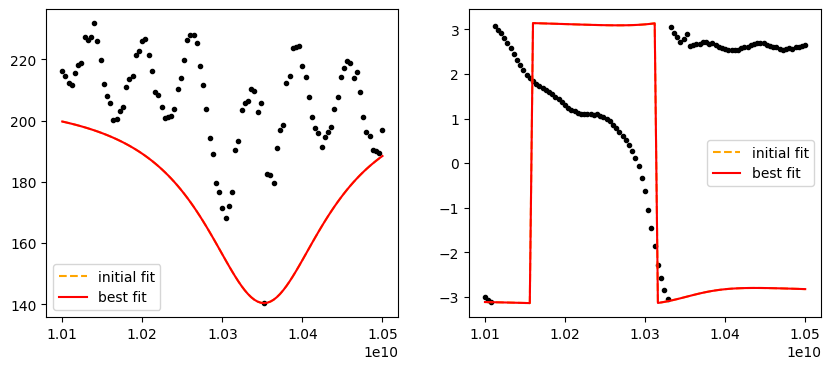

In [17]:
result = resonator_fit_from_dir('/2023-07-19/2023-07-19T132803_a6bbd608-td_spectrum')
result

In [2]:

sp = "/2023-07-19/2023-07-19T132803_a6bbd608-td_spectrum"
dd = datadict_from_hdf5(header + sp +"/data")

In [3]:
def resonator(freq, fc, ke, ki, a0, a1, Poff, ed):
    numer = 1j*(freq-fc)+(ke-ki)/2
    denom = 1j*(freq-fc)-(ke+ki)/2
    return (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(-Poff-ed*2*np.pi*freq))).conj()

In [25]:
def resonator_mag(freq, fc, ke, ki, a0, a1, Poff, ed):
    return np.abs(resonator(freq, fc, ke, ki, a0, a1, Poff, ed))

In [26]:
def resonator_ang(freq, fc, ke, ki, a0, a1, Poff, ed):
    return np.angle(resonator(freq, fc, ke, ki, a0, a1, Poff, ed))

In [6]:
S11 = dd['s11']['values']
mag = np.abs(S11)
ang = np.angle(S11)
freq = dd['frequency']['values']

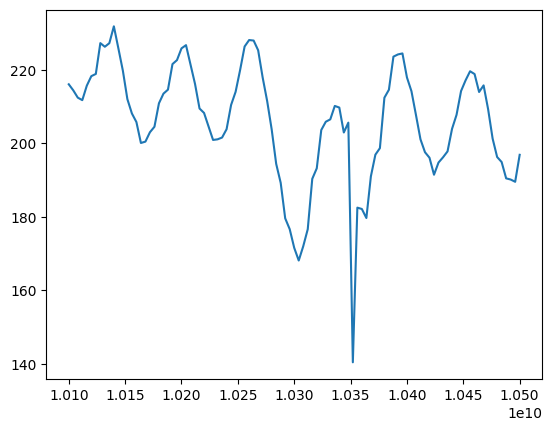

In [10]:
plt.plot(freq, mag)
plt.show()

In [22]:
par_ini = {
    'fc':10.35e9, 
    'ke':50e6, 
    'ki':0, 
    'a0':0, 
    'a1':0, 
    'Poff':0, 
    'ed':0
}

par_min = {
    'fc':0, 
    'ke':0, 
    'ki':0, 
    'a0':-np.inf, 
    'a1':-np.inf, 
    'Poff':-np.inf, 
    'ed':-np.inf
}

par_max = {
    'fc':np.inf, 
    'ke':np.inf, 
    'ki':np.inf, 
    'a0':np.inf, 
    'a1':np.inf, 
    'Poff':np.inf, 
    'ed':np.inf
}

par_vary = {
    'fc':True, 
    'ke':True, 
    'ki':True, 
    'a0':True, 
    'a1':True, 
    'Poff':True, 
    'ed':True
}

In [27]:
model = lmfit.Model(resonator_mag)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [28]:
result = model.fit(data = mag, params=params, freq = freq)
result

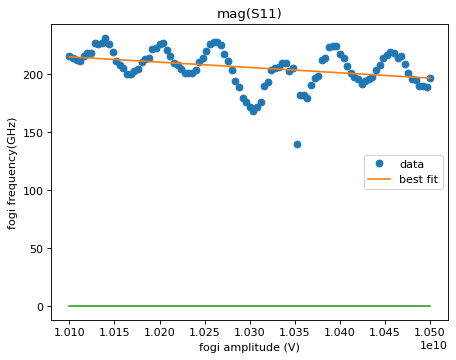

In [29]:
fig, ax = plt.subplots(dpi=80)

plt.title("mag(S11)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq ,result.init_fit)

plt.xlabel("fogi amplitude (V)")
plt.ylabel("fogi frequency(GHz)")


plt.show()

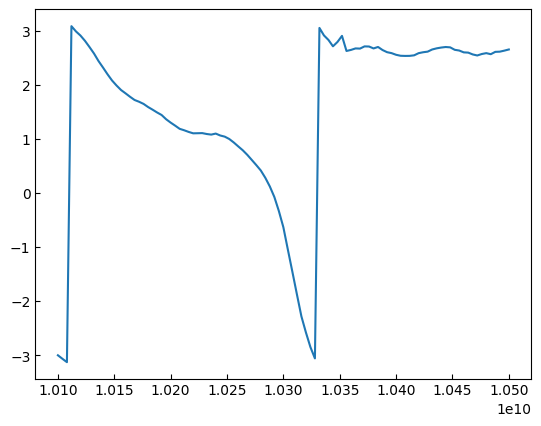

In [30]:
plt.plot(freq, ang)
plt.show()

In [34]:
model = lmfit.Model(resonator_ang)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [36]:
result1 = model.fit(data = ang, params=params, freq = freq)
result1

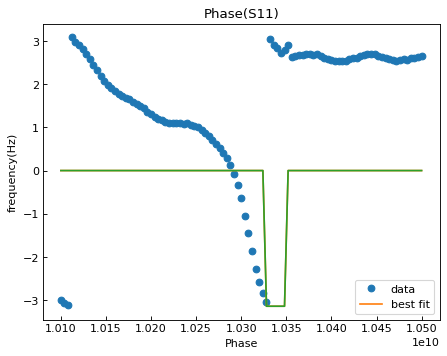

In [38]:
fig, ax = plt.subplots(dpi=80)

plt.title("Phase(S11)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(freq ,result1.init_fit)

plt.xlabel("Phase")
plt.ylabel("frequency(Hz)")


plt.show()